In [38]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

titanic=pd.read_csv(data_url+'titanic.csv')
titanic=titanic.set_index("PassengerId")

In [3]:
print(f"titanic table count >> {titanic.shape}")
print(f"titanic information >> {titanic.info()}")
titanic.head()


titanic table count >> (891, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB
titanic information >> None


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#수치형 열의 기초 통계량 확인
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#Pclass 열의 고유값과 각 값의 빈도를 확인하라
unique_Pclass=titanic['Pclass'].unique()
unique_Pclass

array([3, 1, 2])

In [6]:
titanic['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [7]:
titanic['Survived'].mean()

np.float64(0.3838383838383838)

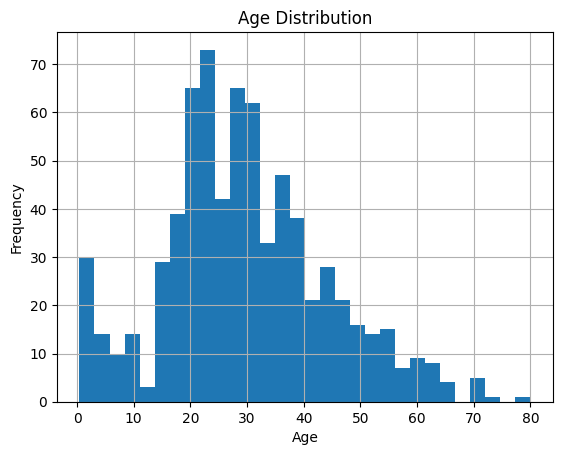

In [8]:
import matplotlib.pyplot as plt
ti_age=titanic['Age']

ti_age.hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

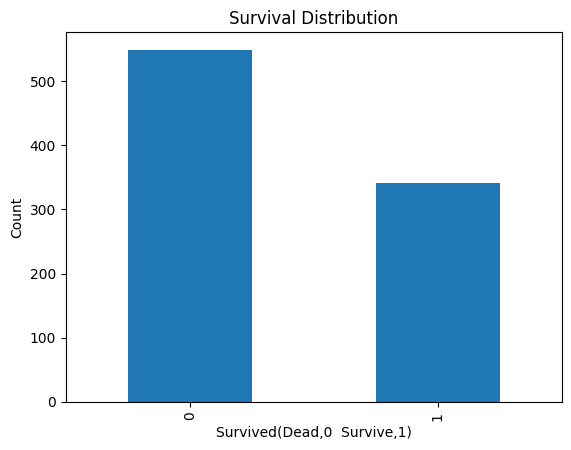

In [9]:
titanic['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived(Dead,0  Survive,1)')
plt.ylabel('Count')
plt.title('Survival Distribution')
plt.show()

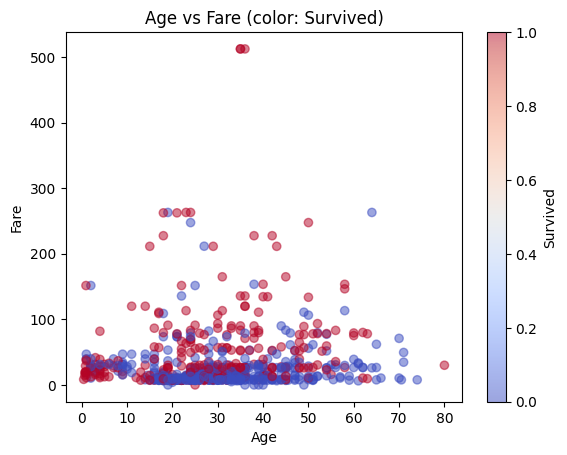

In [10]:
scatter = plt.scatter(
    titanic['Age'], 
    titanic['Fare'], 
    c=titanic['Survived'], 
    cmap='coolwarm', 
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (color: Survived)')

# Pass the scatter object to colorbar
plt.colorbar(label='Survived')

plt.show()


In [11]:
titanic.corr(numeric_only=True)
#타이타닉 데이터 셋의 수치형 열의 상관 행렬

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


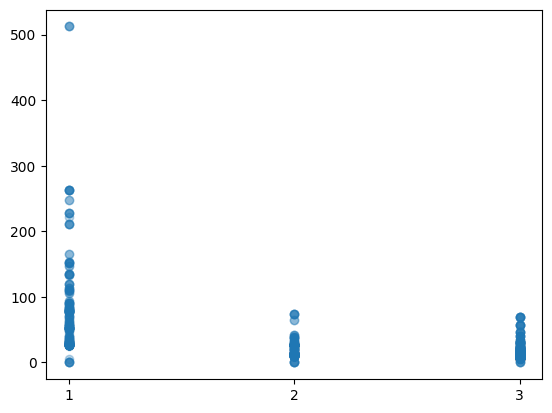

In [12]:
plt.scatter(titanic['Pclass'], titanic['Fare'], alpha=0.3)
plt.xticks([1,2,3])
plt.show()

In [13]:
titanic.corr(numeric_only=True)['Survived'].sort_values()

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

In [14]:
#각 열의 결측치 개수 확인
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [15]:
titanic['Age']=titanic['Age'].fillna(titanic['Age'].median())
titanic['Age'].isnull().sum()

np.int64(0)

In [16]:
titanic['Embarked']=titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic['Embarked'].isnull().sum()

np.int64(0)

In [17]:
titanic.drop(columns='Cabin').isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [18]:
titanic.shape
#타이타닉셋의 행열 개수 확인

(891, 11)

In [19]:
titanic.head()
#타이타닉 셋의 처음 5개 행

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
titanic.info()
#각 열의 데이터 타입과 결측치 개수

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [21]:
titanic.describe()
#타이타닉 수치열의 기초 통계량 확인

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
titanic['Pclass'].unique()
#Pclass의 고유값

array([3, 1, 2])

In [23]:
titanic['Pclass'].value_counts()
#Pclass 빈도수 확인

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [24]:
titanic['Survived'].mean()
#생존자 평균 확인 => 생존률

np.float64(0.3838383838383838)

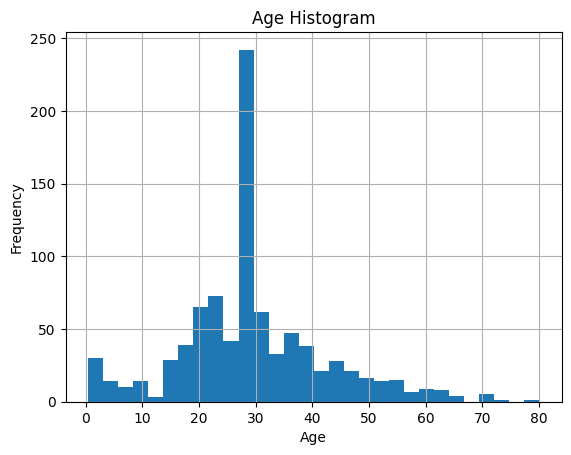

In [25]:
import matplotlib.pyplot as plt
titanic['Age'].hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Histogram')
plt.show()

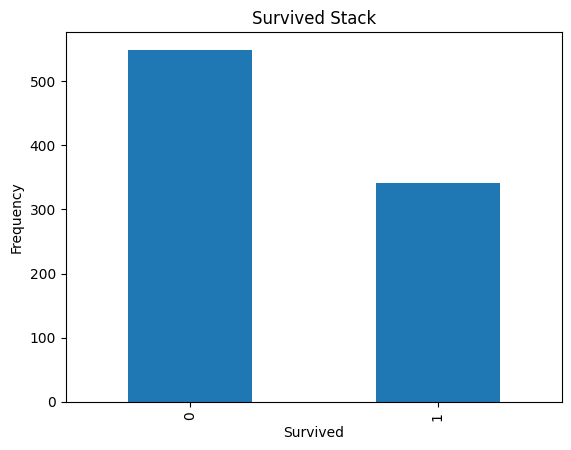

In [26]:
titanic['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived')
plt.ylabel('Frequency')
plt.title('Survived Stack')
plt.show()

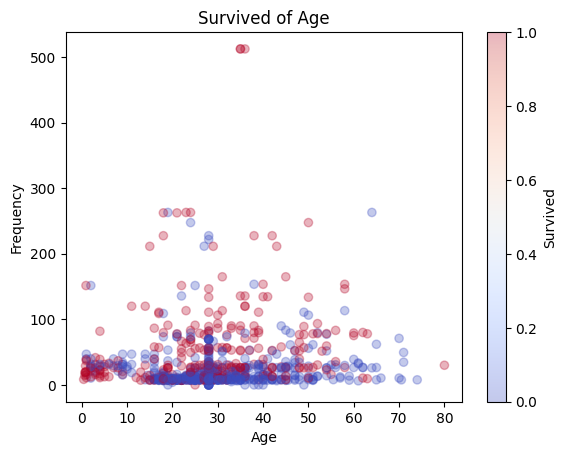

In [27]:
plt.scatter(titanic['Age'], titanic['Fare'], c=titanic['Survived'], cmap='coolwarm', alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Survived of Age')
plt.colorbar(label='Survived')
plt.show()

In [28]:
#타이타닉 상관행렬 구학. 수치형 열만 가능
titanic.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [29]:
#양의 상관 관계 가장 높은 열과 음의 상관 관계 가장 높은 열
titanic.corr(numeric_only=True)['Survived'].sort_values()

Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

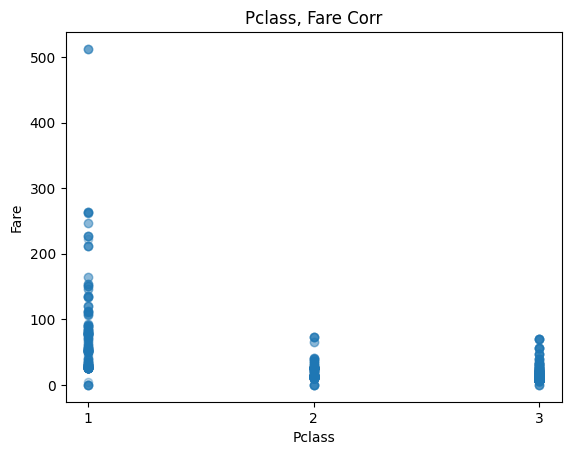

In [30]:
plt.scatter(titanic['Pclass'], titanic['Fare'], alpha=0.3)
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.title('Pclass, Fare Corr')
plt.xticks([1,2,3])
plt.show()


In [33]:
#각 열의 결측치 개수 확인
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

In [40]:
#Age 열의 결측치를 중위수로 채워라
titanic['Age']=titanic['Age'].fillna(titanic['Age'].median())
titanic['Age'].isnull().sum()

np.int64(0)

In [47]:
titanic['Embarked']=titanic['Embarked'].fillna(titanic['Embarked'].mode())
titanic['Embarked'].isnull().sum()

np.int64(0)

In [46]:
titanic.drop(columns='Cabin').isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64